# Notebook 3f — RF con CV por animal: Intensidad IDTC (regresión) **con explotación**
### Tuberculosis bovina

Target: **IDTC** — Intensidad de la reacción intradérmica comparativa a tuberculina (mm).
Variable continua. Pipeline de regresión con Random Forest, CV por animal, incluyendo
**Expl como covariable categórica fija** junto a los biomarcadores.

> **Pregunta de investigación:** ¿añade la explotación capacidad predictiva adicional
> a los biomarcadores para predecir la intensidad de la reacción IDTC?

**Comparar con:**
- *Notebook 2f* (CV sin expl): señal de biomarcadores sin info de granja.
- *Notebook 3e* (Score lesional con expl): misma estrategia, target diferente.
- *Este notebook (3f)*: IDTC con biomarcadores **condicionados a la granja conocida**.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedKFold, KFold)
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy.stats import spearmanr as scipy_spearmanr
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "IDTC")
d = tb.drop_sparse_rows(d)

EXPL_COL = tb.GROUP_COL
FEATURES_BIO = tb.MODEL_FEATURES
FEATURES_ALL = tb.MODEL_FEATURES + [EXPL_COL]

NUM_3F = tb.NUM_FEATURES
CAT_3F = tb.CAT_FEATURES + [EXPL_COL]

X_all = d[FEATURES_ALL].copy()
y     = d["IDTC"].astype(float).values
g     = d[EXPL_COL].values

print(f"Dataset: n={len(y)}")
print(f"IDTC  media={y.mean():.3f}, std={y.std():.3f}, min={y.min():.3f}, max={y.max():.3f}")
print(f"Features biomarcadores ({len(FEATURES_BIO)}): {FEATURES_BIO}")
print(f"Covariable adicional: {EXPL_COL} — niveles: {sorted(d[EXPL_COL].unique())}")
print(f"\nNota: IDTC = Intensidad IDTC (reacción intradérmica comparativa tuberculina).")
print(f"Expl se usa como covariable del modelo (OHE) pero NO para estructurar el CV.")

drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
Dataset: n=103
IDTC  media=11.379, std=6.093, min=0.000, max=32.000
Features biomarcadores (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Covariable adicional: Expl — niveles: ['VA32D', 'VC30D', 'VC94C', 'WZ72B']

Nota: IDTC = Intensidad IDTC (reacción intradérmica comparativa tuberculina).
Expl se usa como covariable del modelo (OHE) pero NO para estructurar el CV.


## 2. Random Forest (regresión) y estrategia de validación cruzada

**CV por animal con Expl como feature fija (RepeatedKFold, 5×10):**
- Sin estratificación (target continuo).
- `Expl` entra como feature categórica (OHE); la selección hacia atrás opera solo sobre biomarcadores.
- Métricas principales: **Spearman r**, **R²**, **RMSE**.

In [2]:
def make_rf_reg(n_estimators=100, min_samples_leaf=5):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_3f(feature_list, n_estimators=100):
    """Pipeline con Expl como covariable categórica fija (regresión)."""
    num_f = [f for f in feature_list if f in NUM_3F]
    cat_f = [f for f in feature_list if f in CAT_3F]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf_reg(n_estimators=n_estimators))])

CV_OUTER_F = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
CV_SEL_F   = RepeatedKFold(n_splits=5, n_repeats=3,  random_state=tb.SEED)

def cv_metrics_3f(bio_features, X, y, cv=None, detailed=False, n_estimators=100):
    """Spearman r, R² y RMSE con CV por animal. Expl siempre incluida."""
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    feats = list(bio_features) + ([EXPL_COL] if EXPL_COL not in bio_features else [])
    Xs = X[feats]
    pipe_tmpl = make_pipe_3f(feats, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        pred = pf.predict(Xs.iloc[te])
        sp   = scipy_spearmanr(y[te], pred).correlation
        r2   = r2_score(y[te], pred)
        rmse = float(np.sqrt(mean_squared_error(y[te], pred)))
        rows.append(dict(spearman=sp, r2=r2, rmse=rmse))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.spearman.mean(), df_r.spearman.std()

print("Evaluación baseline RF regresión (todos los biomarcadores + Expl, CV por animal):")
base_m, base_s = cv_metrics_3f(FEATURES_BIO, X_all, y)
print(f"  Spearman = {base_m:.3f} ± {base_s:.3f}")
print(f"  Modelo nulo (r=0) = referencia")

Evaluación baseline RF regresión (todos los biomarcadores + Expl, CV por animal):


  Spearman = 0.079 ± 0.190
  Modelo nulo (r=0) = referencia


## 3. Pipeline de selección de características

Eliminación hacia atrás sobre **biomarcadores** con `Expl` siempre presente:
1. Importancia de permutación sobre modelo completo → ranking.
2. Eliminación hacia atrás; `Expl` fija en cada paso.
3. Subconjunto más pequeño con Spearman ≥ máx − 1·DE.

Paso 1: Ajustando RF regresión completo (biomarcadores + Expl)...
OOB Score (R², en muestra): -0.081



Ranking importancia de permutación (R², biomarcadores + Expl):
                 pretty  imp_mean  imp_std
log(1+Carga piroplasma)    0.0813   0.0209
                 Calcio    0.0699   0.0135
             Vitamina D    0.0634   0.0157
                   Expl    0.0543   0.0162
            Edad (años)    0.0379   0.0081
                   Raza    0.0301   0.0128
     Theileria spp. (+)    0.0264   0.0094
     Anaplasma spp. (+)    0.0159   0.0046
         Piroplasma (+)    0.0127   0.0066


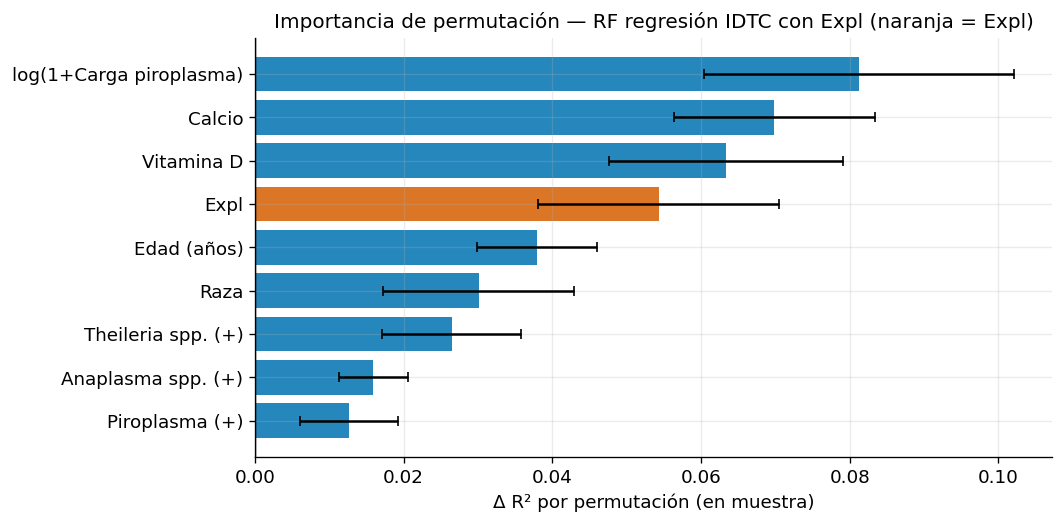

In [3]:
print("Paso 1: Ajustando RF regresión completo (biomarcadores + Expl)...")
full_pipe = make_pipe_3f(FEATURES_ALL).fit(X_all, y)
print(f"OOB Score (R², en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="r2",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  FEATURES_ALL,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (R², biomarcadores + Expl):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = imp_df.sort_values("imp_mean")
colors_bar = [PALETTE[1] if f == EXPL_COL else PALETTE[0] for f in order.feature]
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=colors_bar, capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF regresión IDTC con Expl (naranja = Expl)")
plt.tight_layout(); plt.savefig("figures/fig_03f_perm_importance_full.png"); plt.show()

### 3.1 IC 95% empírico de la importancia de permutación

Percentiles 5/95 empíricos (`np.quantile`, sin asumir normalidad) de las repeticiones de la importancia de permutación (R²) calculada en el paso anterior.


Percentiles empíricos de la importancia de permutación (n_repeats=50):
                 pretty  imp_mean    q05    q95  q_incluye_0
log(1+Carga piroplasma)    0.0813 0.0447 0.1121        False
                 Calcio    0.0699 0.0497 0.0944        False
             Vitamina D    0.0634 0.0413 0.0857        False
                   Expl    0.0543 0.0361 0.0851        False
            Edad (años)    0.0379 0.0247 0.0506        False
                   Raza    0.0301 0.0111 0.0501        False
     Theileria spp. (+)    0.0264 0.0118 0.0399        False
     Anaplasma spp. (+)    0.0159 0.0088 0.0244        False
         Piroplasma (+)    0.0127 0.0000 0.0210        False


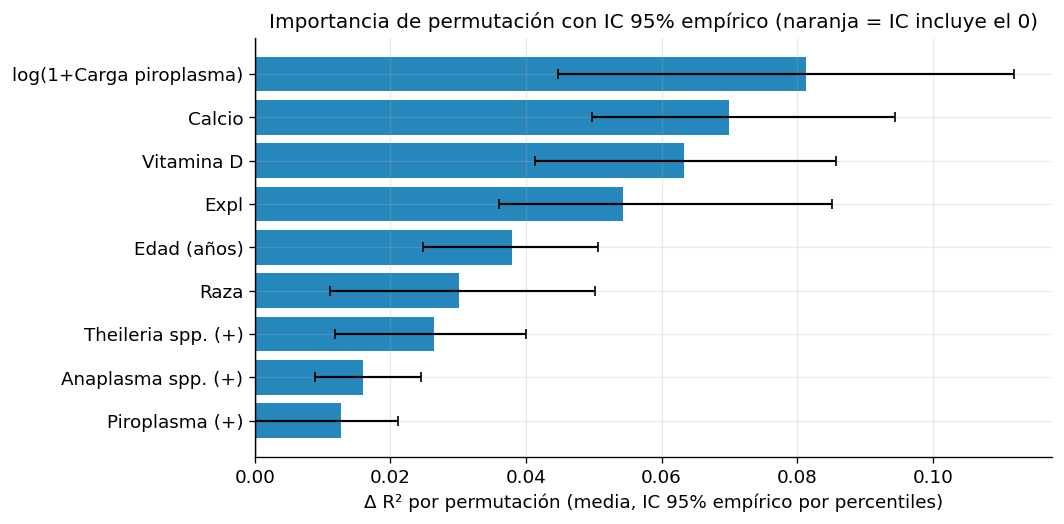

In [4]:
# IC 95% empírico (percentiles de las repeticiones, np.quantile) de la importancia de
# permutación calculada en el paso anterior. No asume normalidad.
feat_idx = {f: i for i, f in enumerate(FEATURES_ALL)}
Q_PROBS = [0.05, 0.95]
Q_COLS  = ["q05", "q95"]

quant_vals = np.array([
    np.quantile(pi.importances[feat_idx[f], :], Q_PROBS)
    for f in imp_df["feature"]
])
for col, vals in zip(Q_COLS, quant_vals.T):
    imp_df[col] = vals
imp_df["q_incluye_0"] = (imp_df["q05"] < 0) & (imp_df["q95"] >= 0)

print(f"Percentiles empíricos de la importancia de permutación (n_repeats={pi.importances.shape[1]}):")
print(imp_df[["pretty", "imp_mean", "q05", "q95", "q_incluye_0"]]
      .round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = imp_df.sort_values("imp_mean")
err = np.vstack([order.imp_mean - order.q05, order.q95 - order.imp_mean])
colors_q = [PALETTE[1] if inc else PALETTE[0] for inc in order.q_incluye_0]
ax.barh(order.pretty, order.imp_mean, xerr=err, color=colors_q, capsize=3, alpha=0.85,
        error_kw=dict(lw=1.3))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (media, IC 95% empírico por percentiles)")
ax.set_title("Importancia de permutación con IC 95% empírico (naranja = IC incluye el 0)")
plt.tight_layout(); plt.savefig("figures/fig_03f_perm_importance_ci95_quantile.png"); plt.show()


In [5]:
bio_imp = imp_df[imp_df.feature != EXPL_COL].sort_values("imp_mean", ascending=True)
elim_order = bio_imp["feature"].tolist()
print(f"Orden de eliminación de biomarcadores: {elim_order}")
print(f"Covariable fija: {EXPL_COL}\n")
print("Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...\n")

current_bio = FEATURES_BIO.copy()
history = []

m0, s0 = cv_metrics_3f(current_bio, X_all, y, cv=CV_SEL_F)
history.append({"n": len(current_bio), "bio_features": current_bio.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_bio):2d} bio + Expl [baseline] Spearman={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_bio or len(current_bio) <= 1: break
    test_bio = [f for f in current_bio if f != feat]
    m, s = cv_metrics_3f(test_bio, X_all, y, cv=CV_SEL_F)
    history.append({"n": len(test_bio), "bio_features": test_bio.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_bio):2d} bio + Expl [-{feat:20s}] Spearman={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_bio = test_bio

hist_df = pd.DataFrame(history)

Orden de eliminación de biomarcadores: ['PIROPLASMA', 'ANAPLASMA', 'THEILERIA', 'RAZA2', 'EDAD', 'VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']
Covariable fija: Expl

Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...



   8 bio + Expl [baseline] Spearman=0.084±0.166


   7 bio + Expl [-PIROPLASMA          ] Spearman=0.035±0.173  Δ=-0.050


   6 bio + Expl [-ANAPLASMA           ] Spearman=0.068±0.159  Δ=-0.017


   5 bio + Expl [-THEILERIA           ] Spearman=0.056±0.138  Δ=-0.028


   4 bio + Expl [-RAZA2               ] Spearman=0.005±0.180  Δ=-0.079


   3 bio + Expl [-EDAD                ] Spearman=0.037±0.206  Δ=-0.047


   2 bio + Expl [-VITAMINA_D          ] Spearman=0.090±0.155  Δ=+0.005


   1 bio + Expl [-CALCIO              ] Spearman=0.158±0.183  Δ=+0.074


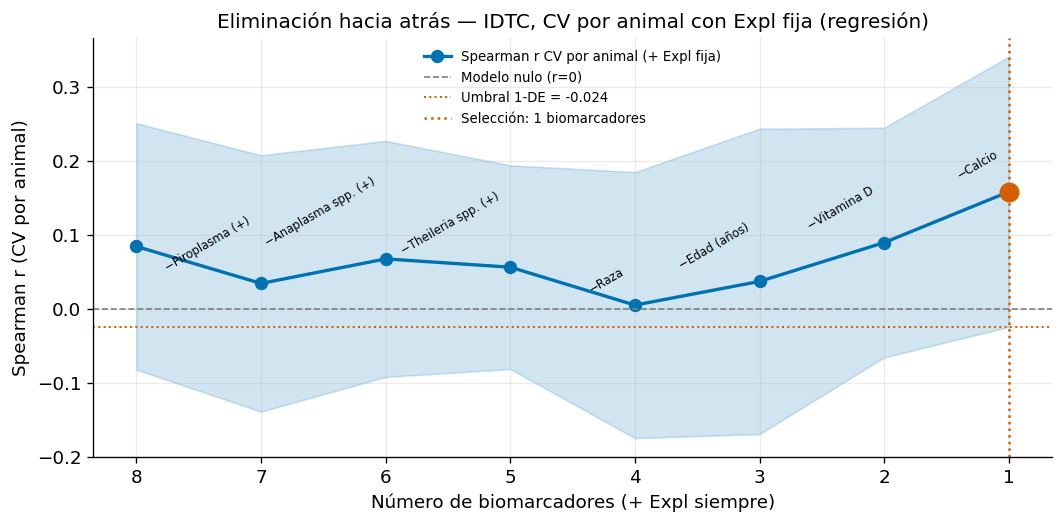


Biomarcadores SELECCIONADOS (1): ['PIROPLASMA_Q_log']


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7,
        label="Spearman r CV por animal (+ Expl fija)")
ax.fill_between(hist_df.n, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"],
                alpha=0.18, color=PALETTE[0])
ax.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (r=0)")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} biomarcadores")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8), fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de biomarcadores (+ Expl siempre)")
ax.set_ylabel("Spearman r (CV por animal)")
ax.set_title("Eliminación hacia atrás — IDTC, CV por animal con Expl fija (regresión)")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_03f_feature_selection_curve.png"); plt.show()

SELECTED_BIO_3F = list(parsimonious.bio_features)
print(f"\nBiomarcadores SELECCIONADOS ({len(SELECTED_BIO_3F)}): {SELECTED_BIO_3F}")

Calculando R² para cada subconjunto (≈1 min)...


   8 bio [-—(baseline)         ] R²=-0.134±0.247


   7 bio [-PIROPLASMA          ] R²=-0.145±0.232


   6 bio [-ANAPLASMA           ] R²=-0.152±0.246


   5 bio [-THEILERIA           ] R²=-0.157±0.249


   4 bio [-RAZA2               ] R²=-0.170±0.230


   3 bio [-EDAD                ] R²=-0.159±0.206


   2 bio [-VITAMINA_D          ] R²=-0.144±0.248


   1 bio [-CALCIO              ] R²=-0.131±0.274


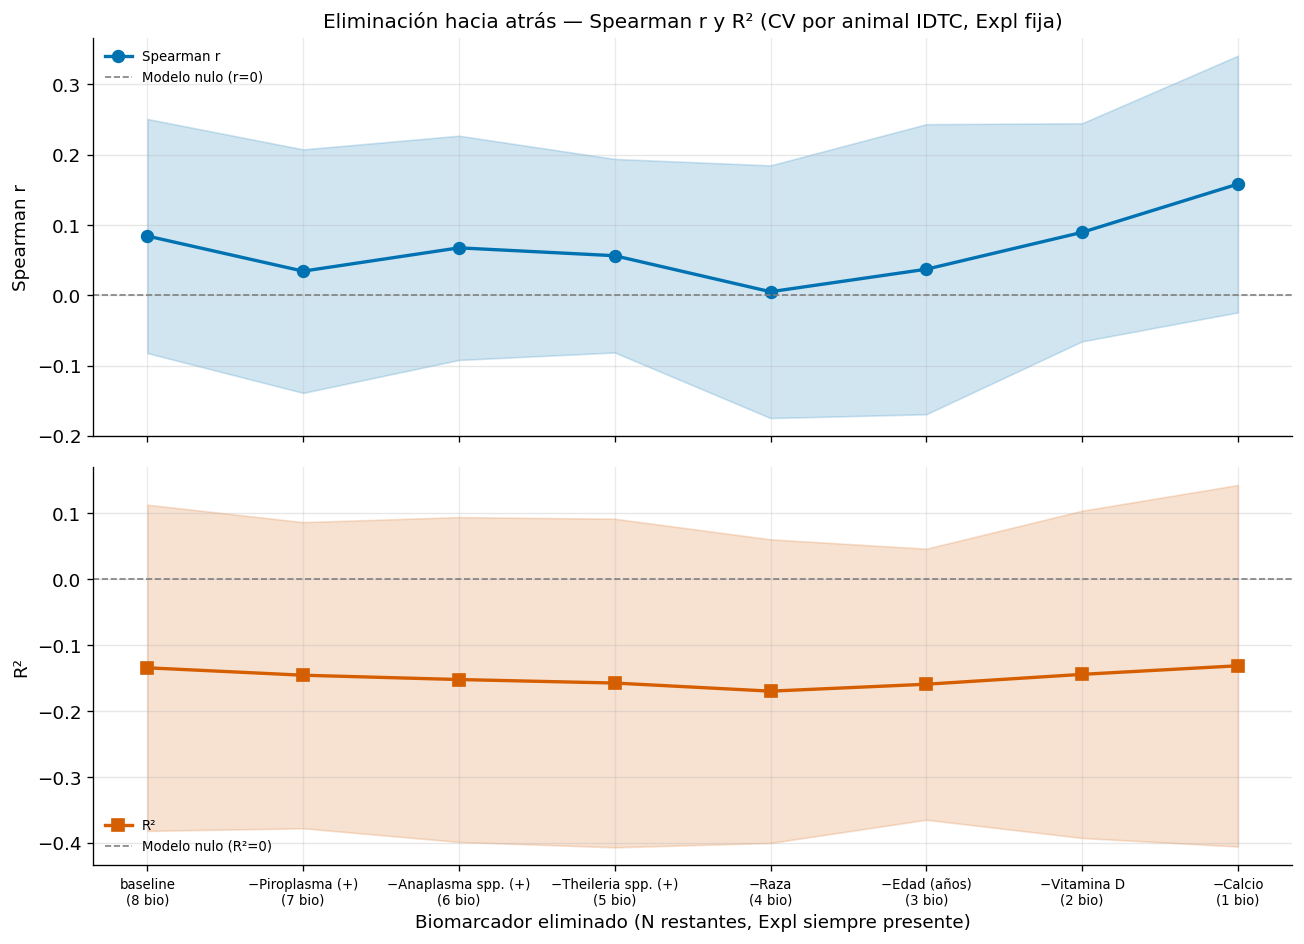

In [7]:
print("Calculando R² para cada subconjunto (≈1 min)...")
r2_means, r2_stds = [], []
for _, row in hist_df.iterrows():
    detailed_tmp = cv_metrics_3f(row["bio_features"], X_all, y, cv=CV_SEL_F, detailed=True)
    r2_means.append(detailed_tmp.r2.mean())
    r2_stds.append(detailed_tmp.r2.std())
    print(f"  {int(row.n):2d} bio [-{row['removed']:20s}] R²={r2_means[-1]:.3f}±{r2_stds[-1]:.3f}")

hist_df = hist_df.assign(r2_mean=r2_means, r2_std=r2_stds)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
x = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} bio)"
    else:
        lbl = f"−{tb.PRETTY.get(row['removed'], row['removed'])}\n({int(row.n)} bio)"
    labels.append(lbl)

ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Spearman r")
ax1.fill_between(x, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"], alpha=0.18, color=PALETTE[0])
ax1.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (r=0)")
ax1.set_ylabel("Spearman r"); ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)
ax1.set_title("Eliminación hacia atrás — Spearman r y R² (CV por animal IDTC, Expl fija)")

ax2 = axes[1]
ax2.plot(x, hist_df["r2_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="R²")
ax2.fill_between(x, hist_df["r2_mean"]-hist_df["r2_std"], hist_df["r2_mean"]+hist_df["r2_std"], alpha=0.18, color=PALETTE[1])
ax2.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (R²=0)")
ax2.set_ylabel("R²"); ax2.legend(fontsize=8); ax2.grid(axis="y", alpha=0.3)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Biomarcador eliminado (N restantes, Expl siempre presente)")
plt.tight_layout()
plt.savefig("figures/fig_03f_feature_selection_metrics.png", bbox_inches="tight")
plt.show()

## 4. Evaluación del modelo final (CV por animal, 5×10)

Modelo final — features (4): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'Expl']



Métricas CV por animal (5×10, con Expl) — IDTC regresión:
  Spearman = 0.068 ± 0.205
  R²       = -0.200 ± 0.376
  RMSE     = 6.228 ± 0.950


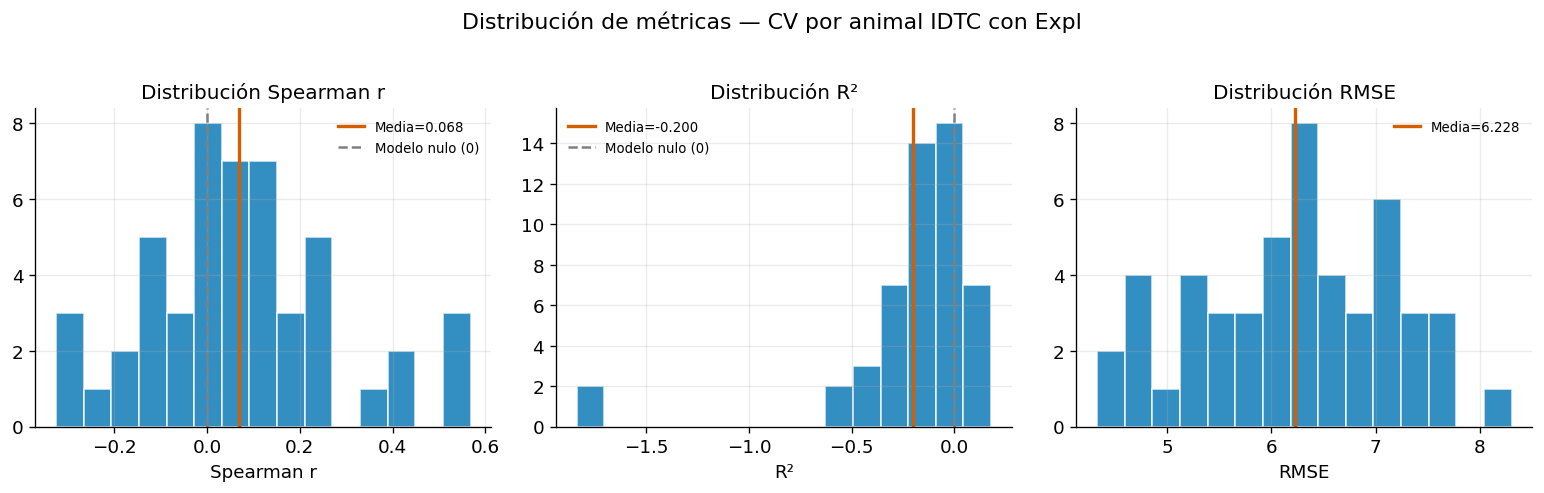

In [8]:
SELECTED_BIO_3F = ["VITAMINA_D", "CALCIO", 'PIROPLASMA_Q_log']  # ajustar si procede
FEATS_FINAL_3F = SELECTED_BIO_3F + [EXPL_COL]
Xs = X_all[FEATS_FINAL_3F].copy()
print(f"Modelo final — features ({len(FEATS_FINAL_3F)}): {FEATS_FINAL_3F}\n")

detailed_df = cv_metrics_3f(
    SELECTED_BIO_3F, X_all, y, cv=CV_OUTER_F, detailed=True, n_estimators=700
)
m = detailed_df.mean(); s = detailed_df.std()

print("Métricas CV por animal (5×10, con Expl) — IDTC regresión:")
print(f"  Spearman = {m.spearman:.3f} ± {s.spearman:.3f}")
print(f"  R²       = {m.r2:.3f} ± {s.r2:.3f}")
print(f"  RMSE     = {m.rmse:.3f} ± {s.rmse:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ["spearman", "r2", "rmse"], ["Spearman r", "R²", "RMSE"]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if col in ("spearman", "r2"):
        ax.axvline(0, color="grey", ls="--", lw=1.5, label="Modelo nulo (0)")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribución de métricas — CV por animal IDTC con Expl", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_03f_metrics_dist.png", bbox_inches="tight")
plt.show()

### 4.1 Predicho vs. real y residuos (CV por animal)

Equivalente, en un modelo de regresión, a la matriz de confusión de los notebooks de clasificación: predicciones out-of-fold agregadas del CV 5×10 (promediadas entre repeticiones para cada animal) frente al valor real, y su distribución de residuos.


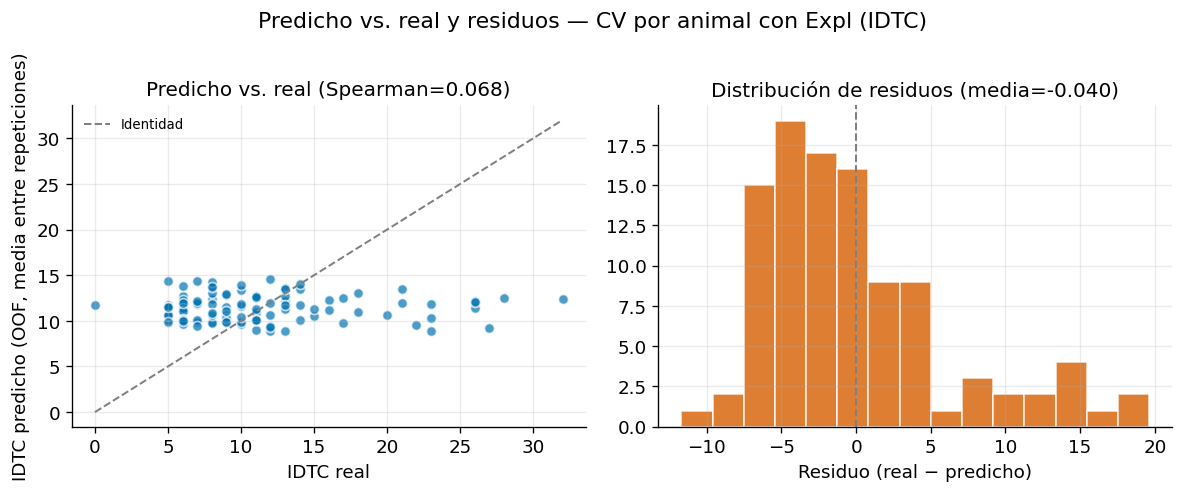

In [9]:
def _oof_predictions_3f(bio_features, X, y, cv, n_estimators=700):
    """Predicciones out-of-fold promediadas entre repeticiones del CV (RepeatedKFold): cada
    animal cae en el fold de test una vez por repetición, y se promedian esas predicciones
    para obtener un único valor predicho por animal (análogo agregado al usado en la matriz
    de confusión de los notebooks de clasificación)."""
    feats = list(bio_features) + ([EXPL_COL] if EXPL_COL not in bio_features else [])
    Xs_ = X[feats]
    pipe_tmpl = make_pipe_3f(feats, n_estimators)
    preds_sum = np.zeros(len(y)); counts = np.zeros(len(y))
    for tr, te in cv.split(Xs_, y):
        pf = clone(pipe_tmpl).fit(Xs_.iloc[tr], y[tr])
        preds_sum[te] += pf.predict(Xs_.iloc[te])
        counts[te] += 1
    return preds_sum / counts

oof_pred_3f = _oof_predictions_3f(SELECTED_BIO_3F, X_all, y, CV_OUTER_F, n_estimators=700)
resid_3f = y - oof_pred_3f

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
ax.scatter(y, oof_pred_3f, color=PALETTE[0], alpha=0.7, edgecolor="white")
lims = [min(y.min(), oof_pred_3f.min()), max(y.max(), oof_pred_3f.max())]
ax.plot(lims, lims, ls="--", color="grey", lw=1.2, label="Identidad")
ax.set_xlabel("IDTC real"); ax.set_ylabel("IDTC predicho (OOF, media entre repeticiones)")
ax.set_title(f"Predicho vs. real (Spearman={m.spearman:.3f})"); ax.legend(fontsize=8)

ax = axes[1]
ax.hist(resid_3f, bins=15, color=PALETTE[1], alpha=0.8, edgecolor="white")
ax.axvline(0, color="grey", ls="--", lw=1.2)
ax.set_xlabel("Residuo (real − predicho)"); ax.set_title(f"Distribución de residuos (media={resid_3f.mean():.3f})")

plt.suptitle("Predicho vs. real y residuos — CV por animal con Expl (IDTC)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_03f_pred_vs_real.png", bbox_inches="tight"); plt.show()


## 5. Interpretabilidad global — SHAP

Las columnas `Expl_*` muestran el efecto granja en la predicción de la intensidad IDTC.
Los valores SHAP de biomarcadores reflejan su contribución **condicionada a la granja**.

In [10]:
FINAL_3F = make_pipe_3f(FEATS_FINAL_3F, n_estimators=500).fit(Xs, y)
print(f"OOB Score (R², en muestra): {FINAL_3F.named_steps['clf'].oob_score_:.3f}")

prep_3f  = FINAL_3F.named_steps["prep"]
clf_3f   = FINAL_3F.named_steps["clf"]
Xt_3f    = prep_3f.transform(Xs)
names_3f = list(prep_3f.get_feature_names_out())

explainer_3f = shap.TreeExplainer(clf_3f)
sv_3f = np.asarray(explainer_3f.shap_values(Xt_3f))
if sv_3f.ndim == 3:
    sv_3f = sv_3f[:, :, 0]

exp_val_3f = float(np.asarray(explainer_3f.expected_value).ravel()[0])

print(f"Features tras preprocesamiento : {names_3f}")
print(f"SHAP values shape              : {sv_3f.shape}")
print(f"Expected value (media predicha): {exp_val_3f:.4f}")

OOB Score (R², en muestra): -0.073
Features tras preprocesamiento : ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'Expl_VA32D', 'Expl_VC30D', 'Expl_VC94C', 'Expl_WZ72B']
SHAP values shape              : (103, 7)
Expected value (media predicha): 11.3529


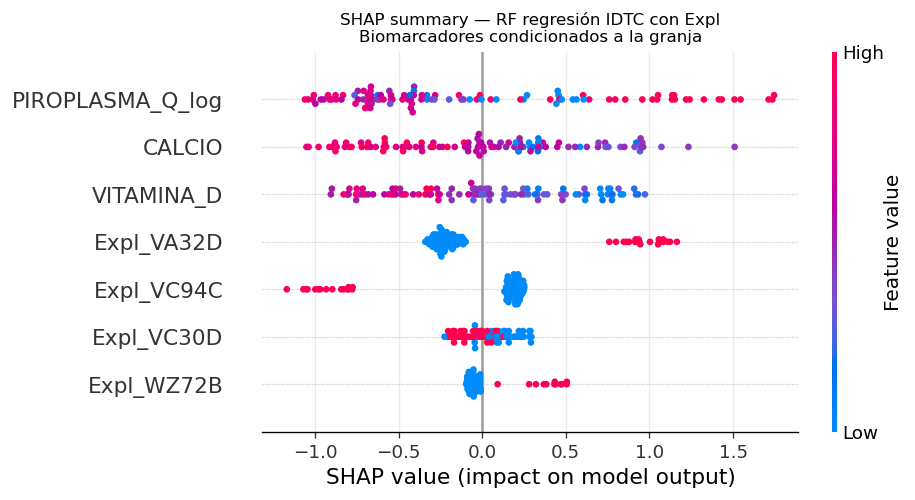

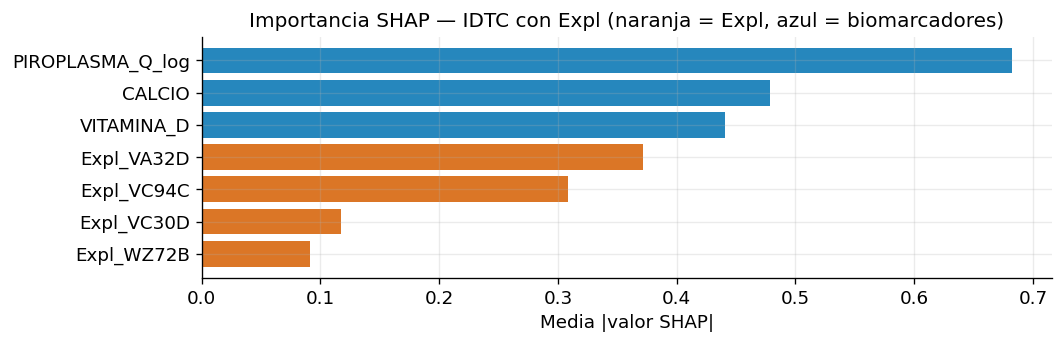

In [11]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_3f))))
shap.summary_plot(sv_3f, Xt_3f, feature_names=names_3f, show=False, max_display=len(names_3f))
plt.title("SHAP summary — RF regresión IDTC con Expl\n"
          "Biomarcadores condicionados a la granja", fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig_03f_shap_summary.png", bbox_inches="tight")
plt.show()

mean_abs_3f = np.abs(sv_3f).mean(0)
si_3f = pd.DataFrame({"feature": names_3f, "mean_abs": mean_abs_3f}).sort_values("mean_abs")
colors_shap = [PALETTE[1] if "Expl" in f else PALETTE[0] for f in si_3f.feature]
fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(names_3f))))
ax.barh(si_3f.feature, si_3f.mean_abs, color=colors_shap, alpha=0.85)
ax.set_xlabel("Media |valor SHAP|")
ax.set_title("Importancia SHAP — IDTC con Expl (naranja = Expl, azul = biomarcadores)")
plt.tight_layout()
plt.savefig("figures/fig_03f_shap_importance.png")
plt.show()

In [12]:
shap.initjs()
order = np.argsort(FINAL_3F.predict(Xs))
fp = shap.force_plot(
    exp_val_3f,
    sv_3f[order, :],
    Xt_3f[order, :] if hasattr(Xt_3f, "__getitem__") else Xt_3f[order],
    feature_names=names_3f,
)
shap.save_html("figures/fig_03f_shap_force_plot_global.html", fp)
display(fp)

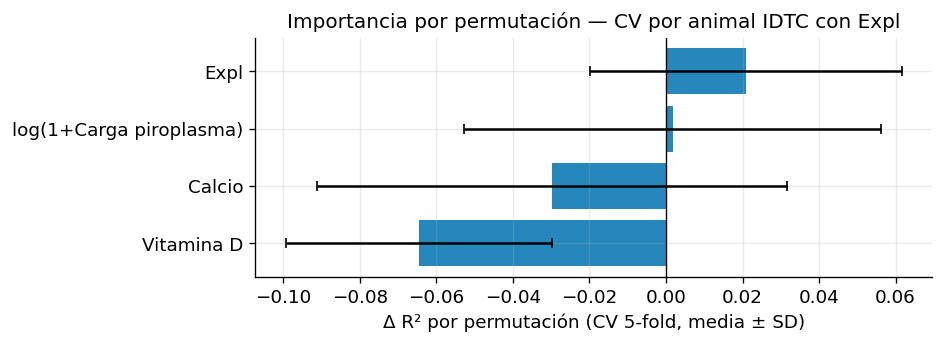

Estabilidad Spearman entre folds: 0.280


In [13]:
from scipy.stats import spearmanr

imp_runs_3f = []
cv_stab = KFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    pf = clone(make_pipe_3f(FEATS_FINAL_3F)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="r2", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_3f.append(pd.Series(pi_f.importances_mean, index=FEATS_FINAL_3F))

imp_mat_3f = pd.concat(imp_runs_3f, axis=1)
imp_ord_3f = imp_mat_3f.mean(axis=1).sort_values().index

R = imp_mat_3f.fillna(0)
cors = [spearmanr(R.iloc[:, i], R.iloc[:, j]).correlation
        for i in range(R.shape[1]) for j in range(i + 1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(FEATS_FINAL_3F))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_3f],
        imp_mat_3f.mean(axis=1)[imp_ord_3f],
        xerr=imp_mat_3f.std(axis=1)[imp_ord_3f],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (CV 5-fold, media ± SD)")
ax.set_title("Importancia por permutación — CV por animal IDTC con Expl")
plt.tight_layout()
plt.savefig("figures/fig_03f_perm_importance_cv.png")
plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


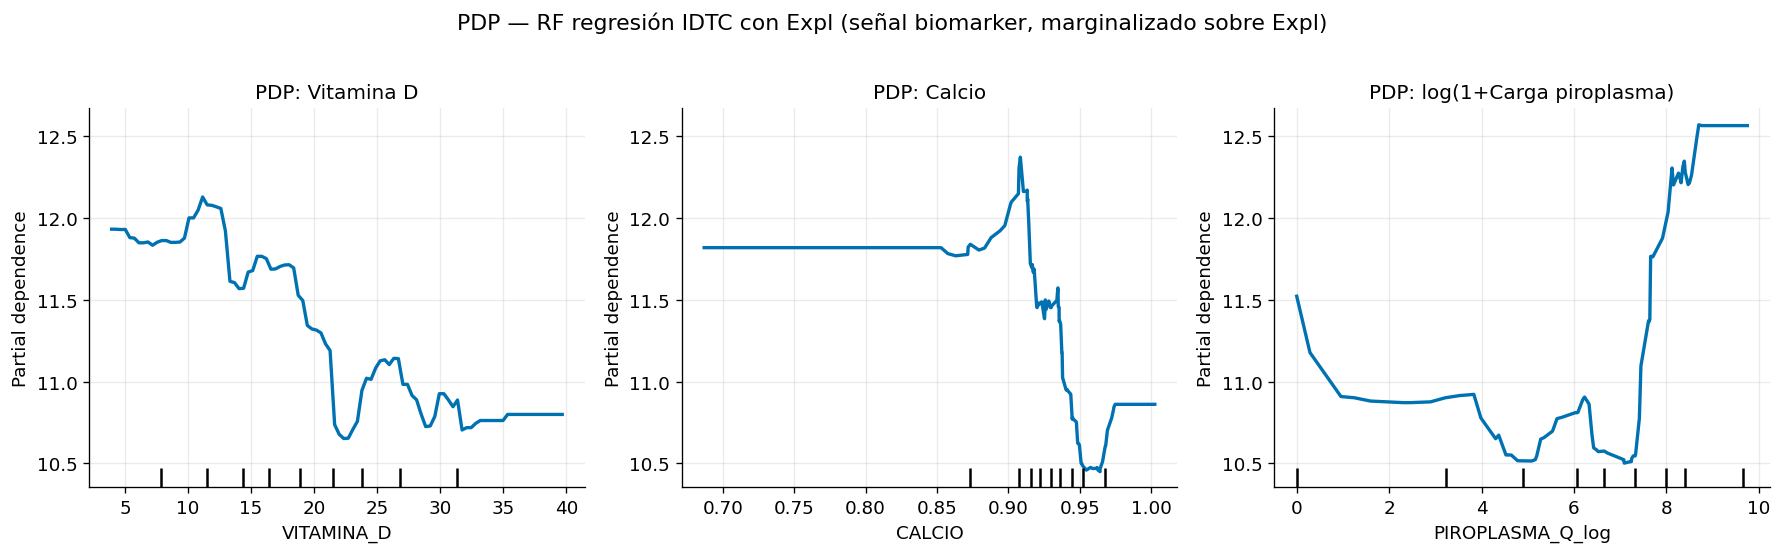

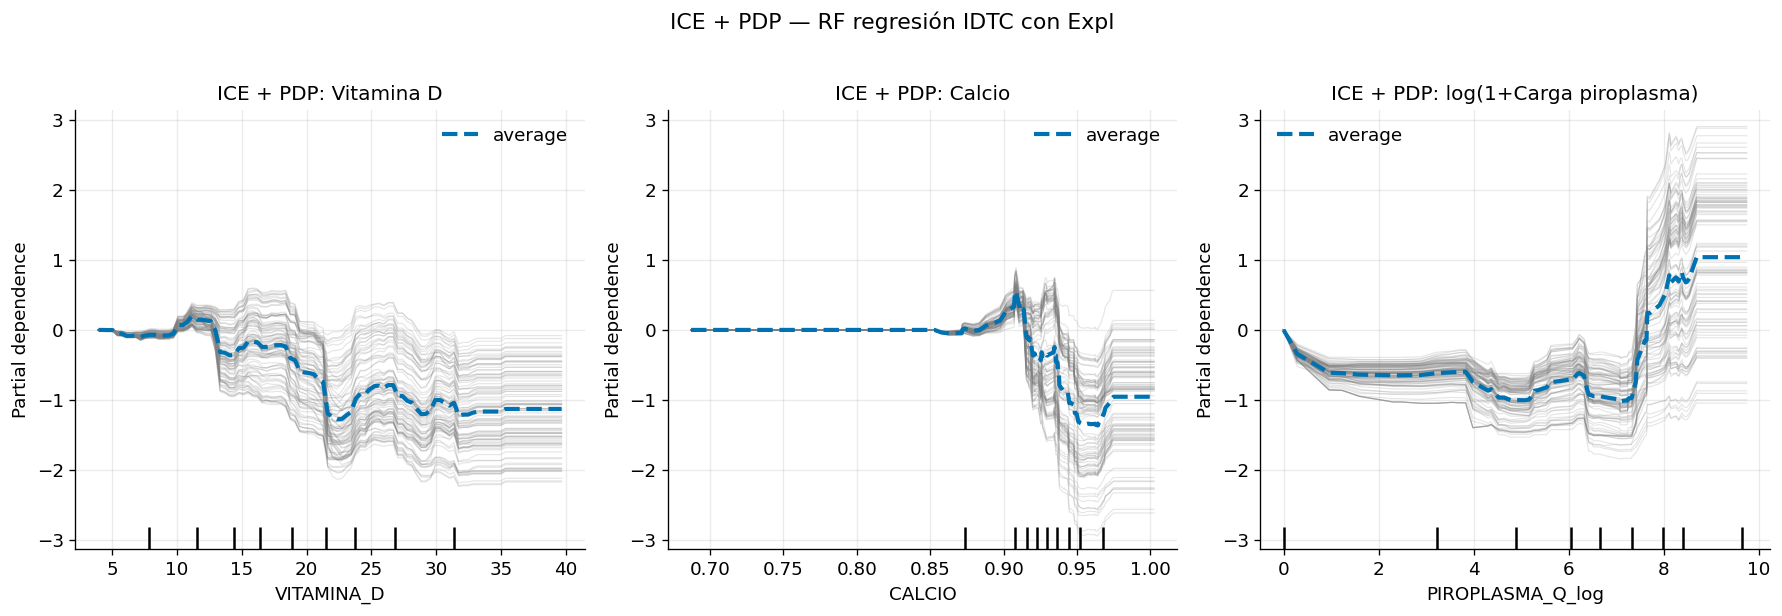

In [14]:
CONT_3F = [f for f in FEATS_FINAL_3F if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_3F:
    CONT_3F = [f for f in FEATS_FINAL_3F if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_3F}")
if CONT_3F:
    n_c = len(CONT_3F)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(
        FINAL_3F, Xs, CONT_3F, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2}
    )
    for ax, f in zip(axes, CONT_3F):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP — RF regresión IDTC con Expl (señal biomarker, marginalizado sobre Expl)", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/fig_03f_pdp.png", bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(
        FINAL_3F, Xs, CONT_3F, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True
    )
    for ax, f in zip(axes, CONT_3F):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP — RF regresión IDTC con Expl", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/fig_03f_ice.png", bbox_inches="tight")
    plt.show()

### 6.1 PDP para variables categóricas

PDP categórico para las variables de `FEATS_FINAL_3F` que quedan fuera de `CONT_3F` (p. ej. `Expl` y biomarcadores serológicos binarios): se sustituye el valor por cada nivel en toda la muestra y se promedia la predicción de IDTC.


Features categóricas/discretas para PDP: ['Expl']


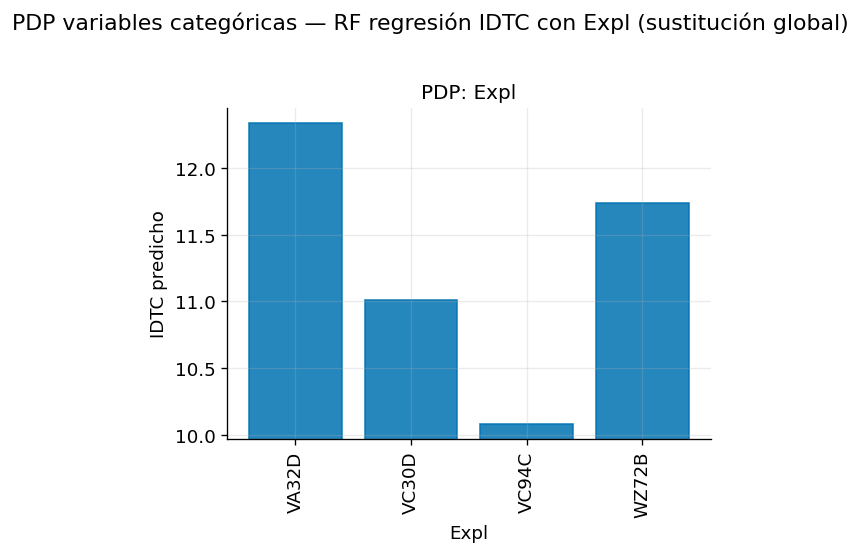

In [15]:
CAT_3F_PLOT = [f for f in FEATS_FINAL_3F if f not in CONT_3F]
print(f"Features categóricas/discretas para PDP: {CAT_3F_PLOT}")

if CAT_3F_PLOT:
    n_cat = len(CAT_3F_PLOT)
    fig, axes = plt.subplots(1, n_cat, figsize=(5 * n_cat, 4.5))
    if n_cat == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(
        FINAL_3F, Xs, CAT_3F_PLOT, kind="average",
        categorical_features=CAT_3F_PLOT, ax=axes)
    for ax, f in zip(axes, CAT_3F_PLOT):
        for bar in ax.patches:
            bar.set_color(PALETTE[0]); bar.set_alpha(0.85)
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
        ax.set_ylabel("IDTC predicho")
    plt.suptitle("PDP variables categóricas — RF regresión IDTC con Expl (sustitución global)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03f_pdp_cat.png", bbox_inches="tight"); plt.show()
else:
    print("No hay variables categóricas adicionales fuera de CONT_3F.")


## 7. Accumulated Local Effects (ALE)

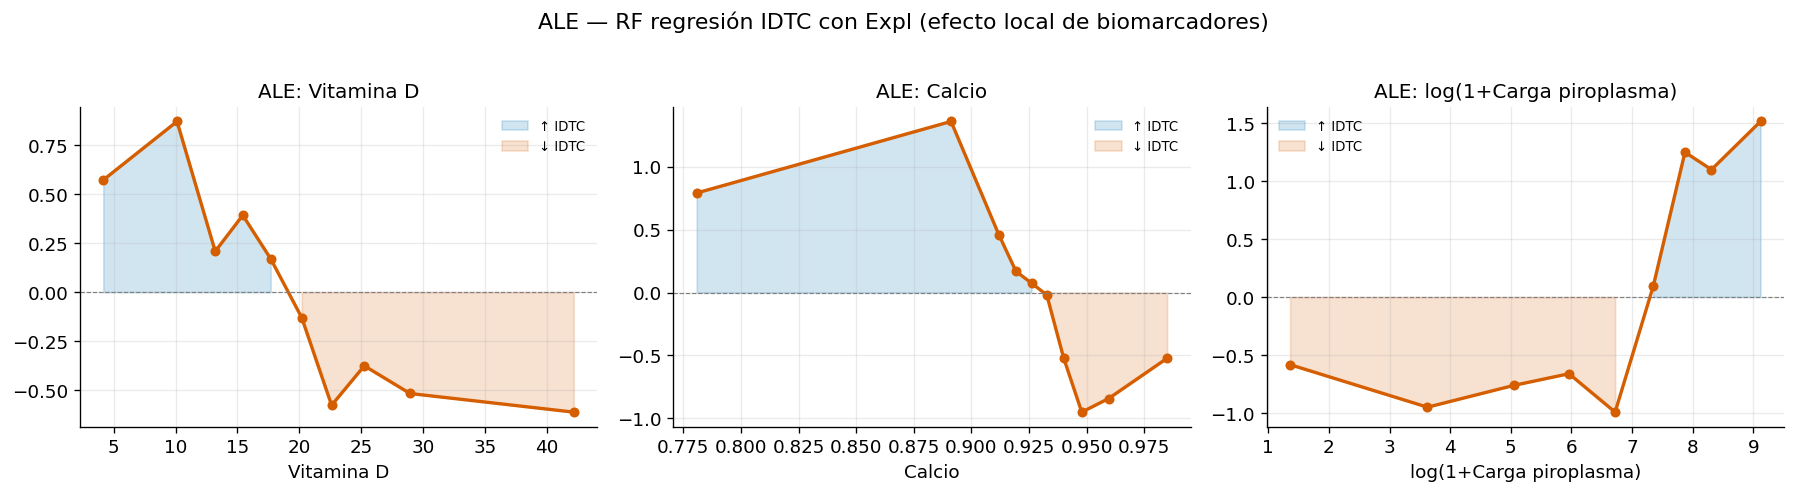

In [16]:
def ale_1d_reg(model, X, feat, bins=10):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict(hi) - model.predict(lo)).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_3F:
    n_c = len(CONT_3F)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3F):
        cx, ale = ale_1d_reg(FINAL_3F, Xs, feat)
        if len(cx) == 0:
            ax.set_title(f"ALE: {tb.PRETTY.get(feat, feat)}\n(insuf.)")
            continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0],
                        label="↑ IDTC")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1],
                        label="↓ IDTC")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat, feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.legend(fontsize=8)
    plt.suptitle("ALE — RF regresión IDTC con Expl (efecto local de biomarcadores)", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/fig_03f_ale.png", bbox_inches="tight")
    plt.show()

## 8. SHAP waterfall — interpretabilidad local

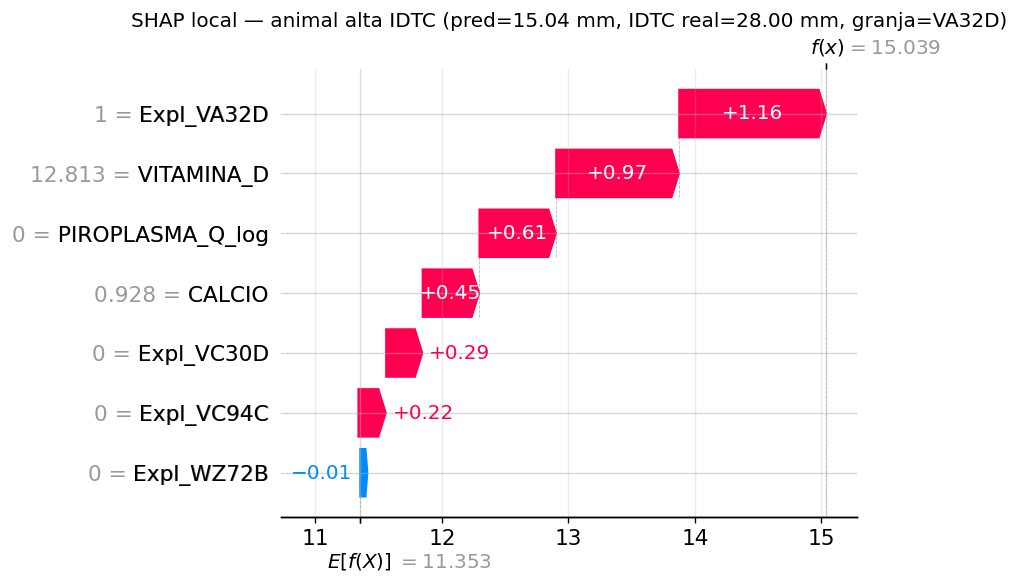

Animal 76: pred=15.04, IDTC real=28.00, granja=VA32D


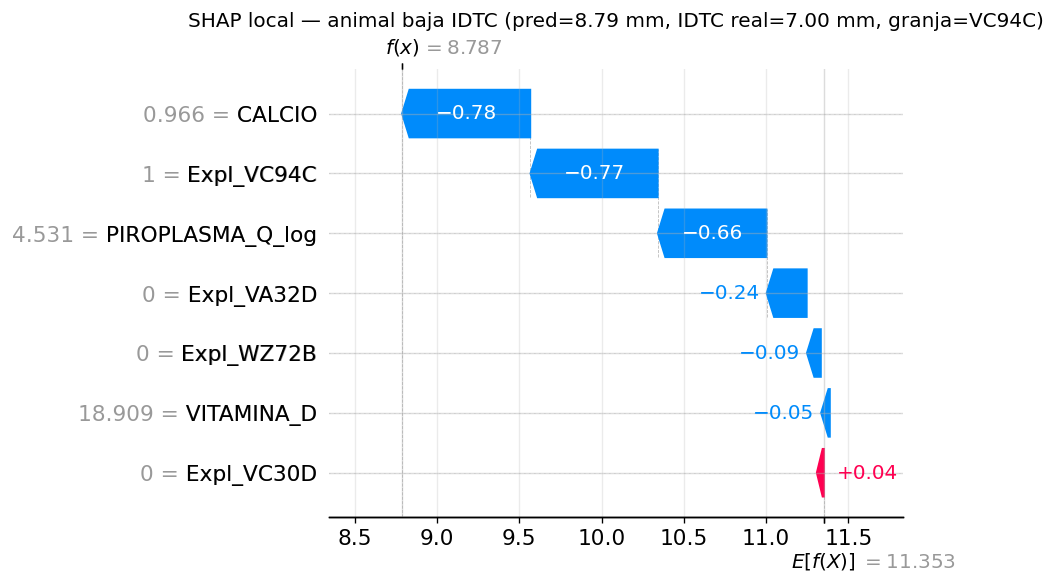

Animal 66: pred=8.79, IDTC real=7.00, granja=VC94C


In [17]:
pred_all_3f = FINAL_3F.predict(Xs)
idx_high    = int(np.argmax(pred_all_3f))
idx_low     = int(np.argmin(pred_all_3f))

shap_exp_3f = shap.Explanation(
    values=sv_3f, base_values=exp_val_3f,
    data=Xt_3f, feature_names=names_3f
)

for tag, idx in [("alta_IDTC", idx_high), ("baja_IDTC", idx_low)]:
    farm_ref = g[idx]
    fig, _ = plt.subplots(figsize=(10, 4))
    shap.plots.waterfall(shap_exp_3f[idx], max_display=len(names_3f), show=False)
    plt.title(
        f"SHAP local — animal {tag.replace('_', ' ')} "
        f"(pred={pred_all_3f[idx]:.2f} mm, IDTC real={y[idx]:.2f} mm, granja={farm_ref})"
    )
    plt.tight_layout()
    plt.savefig(f"figures/fig_03f_waterfall_{tag}.png", bbox_inches="tight")
    plt.show()
    print(f"Animal {idx}: pred={pred_all_3f[idx]:.2f}, IDTC real={y[idx]:.2f}, granja={farm_ref}")

## 9. Contrafactuales (sobre biomarcadores, granja fija)

In [18]:
def find_cf_reg(model, row_dict, feat, lo, hi, threshold, direction="above", n=500):
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        pred = model.predict(pd.DataFrame([r]))[0]
        if direction == "above" and pred >= threshold: return v, pred
        if direction == "below" and pred <= threshold: return v, pred
    return None, None

high_row = Xs.iloc[idx_high].copy()
low_row  = Xs.iloc[idx_low].copy()

threshold_idtc = float(y.mean())
print(f"Umbral de referencia IDTC = {threshold_idtc:.2f} mm (media observada)")

print("=" * 60)
print("CONTRAFACTUALES — biomarcadores (granja fija, IDTC regresión)")
print("=" * 60)
for tag, row, direction in [
    ("ALTA IDTC predicha",  high_row, "below"),
    ("BAJA IDTC predicha",  low_row,  "above"),
]:
    pred = FINAL_3F.predict(pd.DataFrame([row]))[0]
    print(f"\nAnimal {tag} (pred={pred:.2f} mm, granja={row[EXPL_COL]}), objetivo → "
          f"{'< ' if direction=='below' else '≥ '}{threshold_idtc:.2f} mm")
    for feat in CONT_3F:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf_v, cf_pred = find_cf_reg(
            FINAL_3F, row.to_dict(), feat, lo_v, hi_v,
            threshold_idtc, direction=direction
        )
        cur = row[feat]
        if cf_v is not None:
            print(f"  {tb.PRETTY.get(feat, feat):30s}: actual={cur:.2f} → cf={cf_v:.2f} "
                  f"(Δ={cf_v - cur:+.2f}, pred_cf={cf_pred:.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat, feat):30s}: actual={cur:.2f} → no alcanzable en rango observado")

Umbral de referencia IDTC = 11.38 mm (media observada)
CONTRAFACTUALES — biomarcadores (granja fija, IDTC regresión)

Animal ALTA IDTC predicha (pred=15.04 mm, granja=VA32D), objetivo → < 11.38 mm


  Vitamina D                    : actual=12.81 → no alcanzable en rango observado


  Calcio                        : actual=0.93 → no alcanzable en rango observado


  log(1+Carga piroplasma)       : actual=0.00 → no alcanzable en rango observado

Animal BAJA IDTC predicha (pred=8.79 mm, granja=VC94C), objetivo → ≥ 11.38 mm


  Vitamina D                    : actual=18.91 → no alcanzable en rango observado


  Calcio                        : actual=0.97 → no alcanzable en rango observado


  log(1+Carga piroplasma)       : actual=4.53 → no alcanzable en rango observado


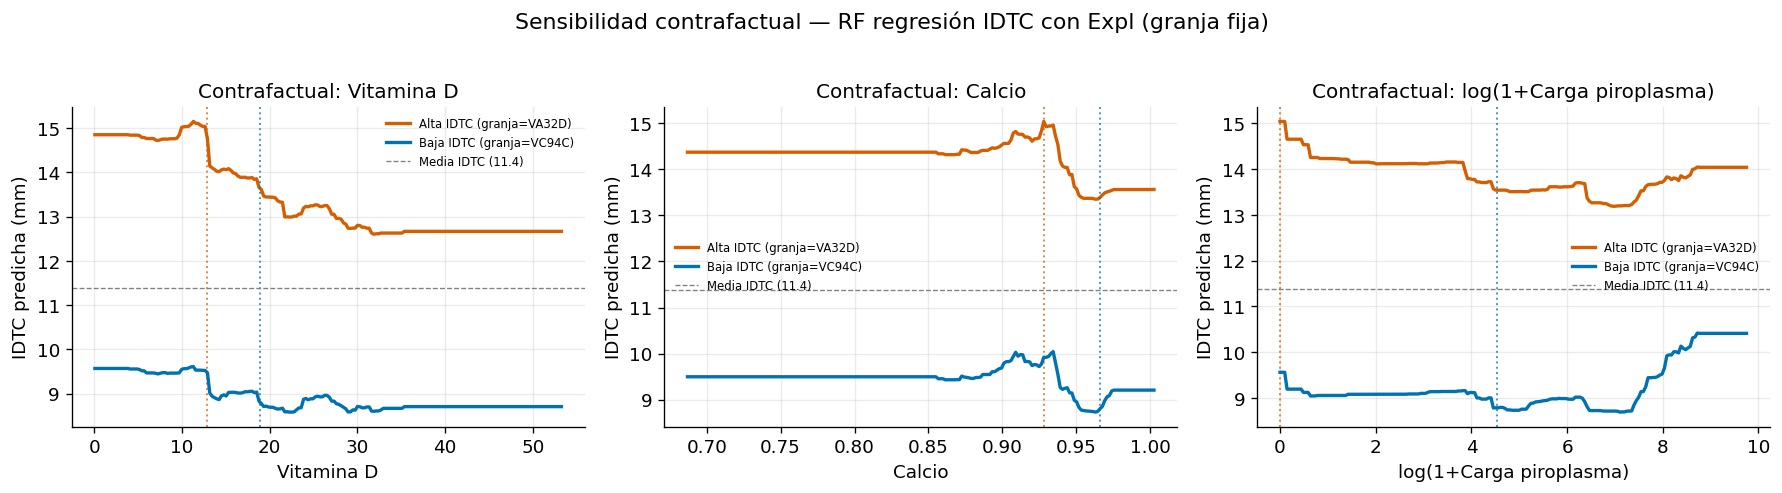

In [19]:
if CONT_3F:
    n_c = len(CONT_3F)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3F):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [
            ("Alta IDTC", high_row, PALETTE[1]),
            ("Baja IDTC", low_row,  PALETTE[0]),
        ]:
            preds_grid = [
                FINAL_3F.predict(pd.DataFrame([{**row.to_dict(), feat: v}]))[0]
                for v in grid
            ]
            ax.plot(grid, preds_grid, color=color, lw=2, label=f"{tag} (granja={row[EXPL_COL]})")
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(threshold_idtc, color="grey", ls="--", lw=0.8,
                   label=f"Media IDTC ({threshold_idtc:.1f})")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.set_ylabel("IDTC predicha (mm)")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat, feat)}")
        ax.legend(fontsize=7)
    plt.suptitle("Sensibilidad contrafactual — RF regresión IDTC con Expl (granja fija)", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/fig_03f_cf_curves.png", bbox_inches="tight")
    plt.show()

## 10. Síntesis y triangulación

### Tabla de métricas

| Métrica | Nb 2f — CV sin expl | **Nb 3f — CV + Expl fija** |
|---|---|---|
| Spearman r | — | **—** |
| R² | — | **—** |
| RMSE (mm) | — | **—** |
| Expl como feature | No | **Sí (OHE, siempre fija)** |

### Guía de interpretación

- **Si Spearman(3f) >> Spearman(2f):** la explotación aporta señal incremental para predecir
  la intensidad IDTC; la granja modula la respuesta inmune cutánea de forma detectada por el modelo.

- **Si Spearman(3f) ≈ Spearman(2f):** la identidad de la granja no añade valor predictivo
  para la IDTC; los biomarcadores individuales explican la variabilidad de la respuesta cutánea.

- **SHAP de Expl_*:** si las columnas de granja tienen SHAP elevado, la intensidad IDTC
  está modulada por factores de granja (cepa, exposición, historial de vacunación, manejo)
  más allá de los biomarcadores sistémicos medidos.

### Implicaciones clínicas

Si la intensidad IDTC es predecible condicionando a la granja, sugiere que:
1. El historial de granja (cepa circulante, nivel de exposición) podría usarse para
   ajustar umbrales de IDTC en las campañas de saneamiento.
2. Los biomarcadores sistémicos medidos (vitamina D, calcio, serología parasitaria)
   modulan la respuesta cutánea de forma diferente según el contexto de granja.
3. La comparación con Nb 2f (sin Expl) cuantifica cuánta variabilidad adicional
   de la respuesta IDTC se explica por la identidad de la granja.